In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

import torch
import torchvision
from torch import nn
from torch.utils.data import Dataset, DataLoader,WeightedRandomSampler
from torchvision.transforms.v2 import Compose, Normalize
from torch.utils.data import random_split

from sklearn.metrics import f1_score, confusion_matrix, classification_report


import model_checks



%load_ext autoreload
%autoreload 2

## Generate Dataset

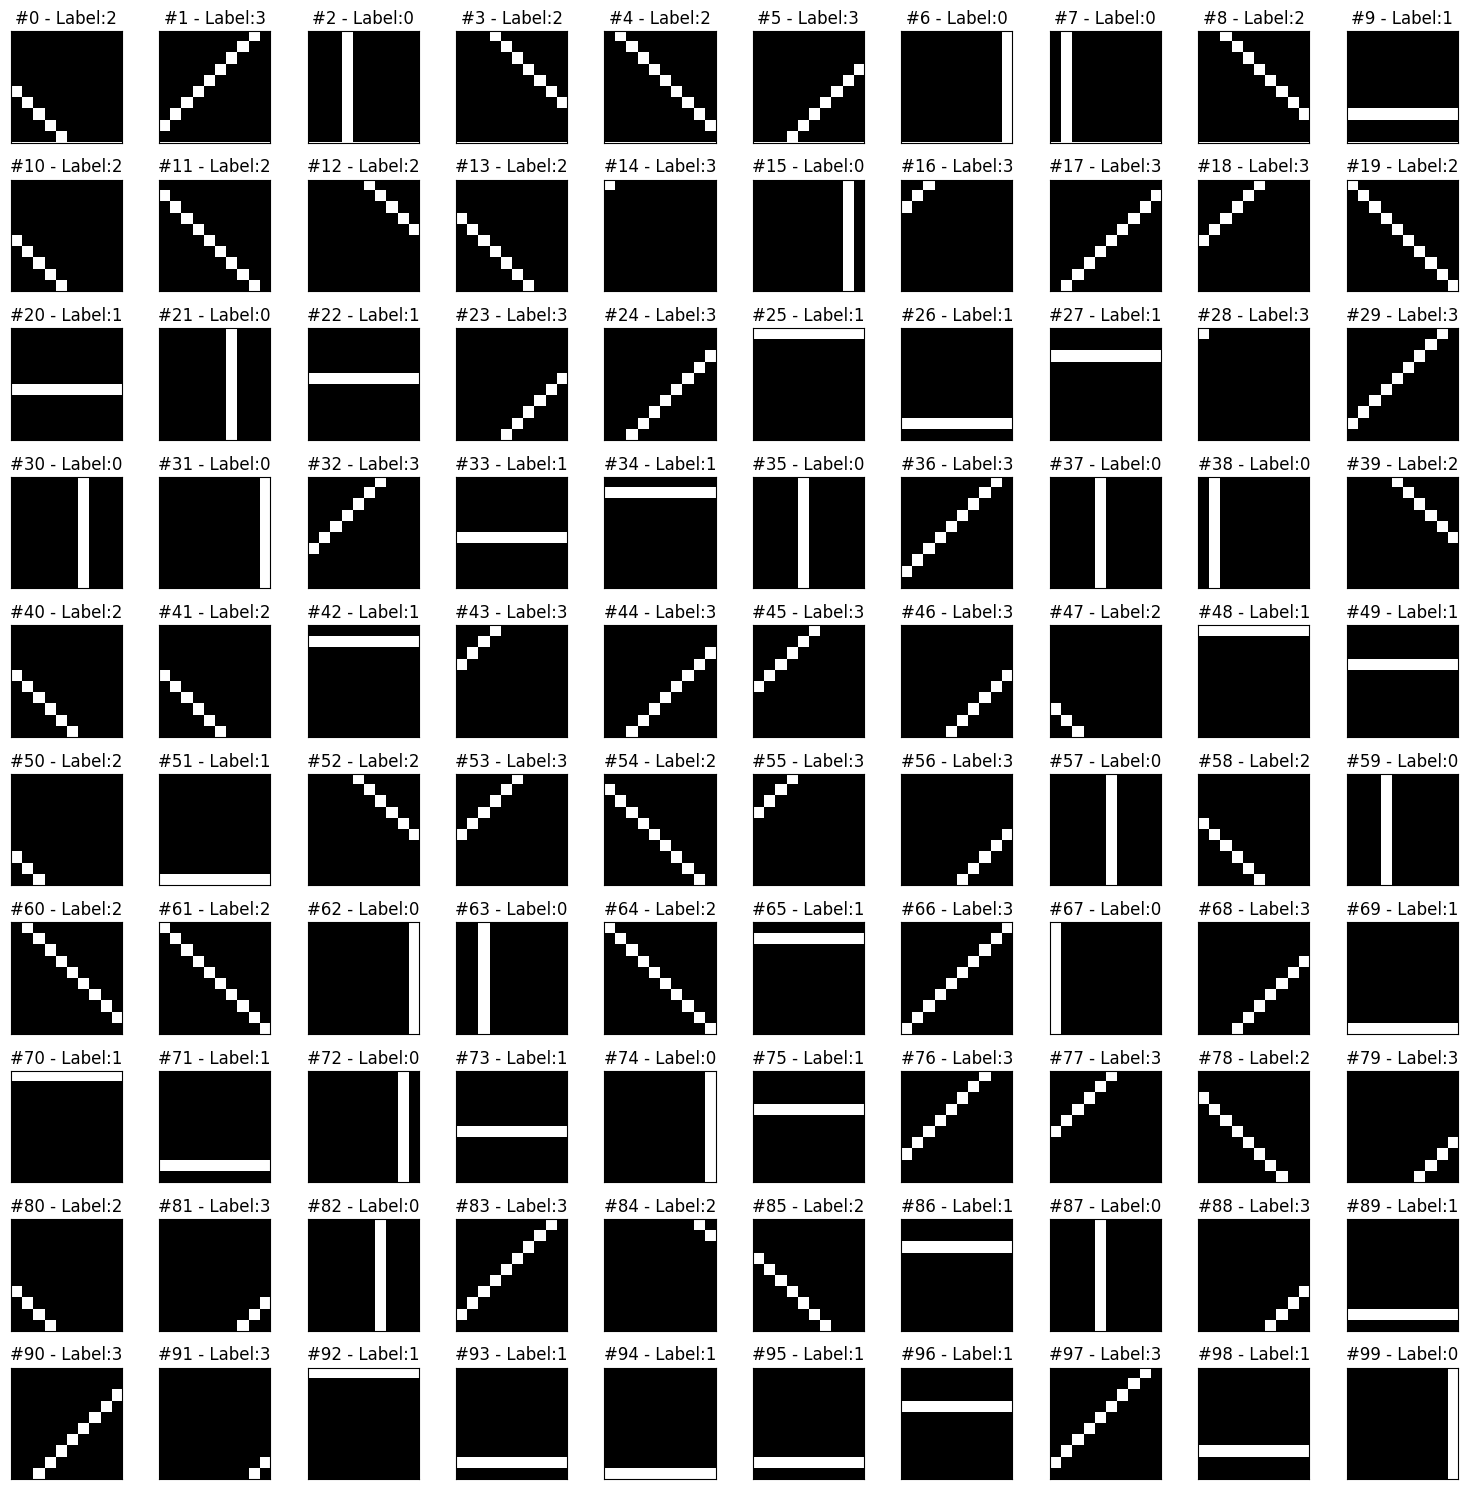

In [2]:

def diagonal_line(img,row0,col0,img_size,orientation):
    coord_col=np.arange(0,img_size)


    if orientation=="right":
        coord_row=coord_col+row0-col0
    else:
        coord_row=-coord_col+row0+col0

    coords = np.column_stack((coord_row,coord_col))
    coords = coords[(coords >= 0).all(axis=1)]
    coords = coords[(coords < img_size).all(axis=1)]
    img[coords[:,0],coords[:,1]]=1

    return img
        


def gen_img(img_size,direction):
    img=np.zeros((img_size,img_size))
    start_row=np.random.randint(img_size)
    start_col=np.random.randint(img_size)


    if direction == 0:
        #"vertical"
        img[:, start_col] = 1

    elif direction == 1:
        #"horizontal"
        img[start_row, :] = 1

    elif direction == 2 :
        #"diagonal_right"
        img = diagonal_line(img, start_row, start_col, img_size, "right")

    elif direction == 3 :
        #"diagonal_left"
        img = diagonal_line(img, start_row, start_col, img_size, "left")
        

    return img.reshape(1,img_size,img_size)

def plot_images(images, targets, n_plot=30):
    n_rows = n_plot // 10 + ((n_plot % 10) > 0)
    fig, axes = plt.subplots(n_rows, 10, figsize=(15, 1.5 * n_rows))
    axes = np.atleast_2d(axes)

    for i, (image, target) in enumerate(zip(images[:n_plot], targets[:n_plot])):
        row, col = i // 10, i % 10    
        ax = axes[row, col]
        ax.set_title('#{} - Label:{}'.format(i, target), {'size': 12})
        # plot filter channel in grayscale
        ax.imshow(image.squeeze(), cmap='gray', vmin=0, vmax=1)

    for ax in axes.flat:
        ax.set_xticks([])
        ax.set_yticks([])
        ax.label_outer()

    plt.tight_layout()
    return fig




n_images=1000
img_size=10
SEED = 42
np.random.seed(SEED)
label=np.random.randint(low=0, high=4,size=n_images)
images = np.array([gen_img(img_size,target) for target in label],dtype=np.uint8)



plot_images(images,label, n_plot=100);


In [3]:
# check the data inbalance
values, counts = np.unique(label, return_counts=True)

print(values)
print(counts)

[0 1 2 3]
[258 230 232 280]


## Create TorchDataset

In [4]:
class DatasetTransform(Dataset):
    def __init__(self,x,y,transform=None):
        self.x=x
        self.y=y
        self.transform=transform
    def __getitem__(self, index):
        x=self.x[index]
        if self.transform:
            x=self.transform(x)
        return x, self.y[index]
    
    def __len__(self):
        return len(self.x)

In [5]:
x_tensor=torch.as_tensor(images).float()
y_tensor=torch.as_tensor(label).long()

### Split train and validation set
n = len(x_tensor)
# Create reproducible random indices
generator = torch.Generator().manual_seed(42)
indices = torch.randperm(n, generator=generator)

# 80% train, 20% validation
train_size = int(0.8 * n)

train_idx = indices[:train_size]
val_idx = indices[train_size:]

# Use the same indices for X and y
x_train = x_tensor[train_idx]
y_train = y_tensor[train_idx]

x_val = x_tensor[val_idx]
y_val = y_tensor[val_idx]

compose = Compose([Normalize(mean=[0.5], std=[0.5])])
train_dataset= DatasetTransform(x_train,y_train,compose)
val_dataset= DatasetTransform(x_val,y_val,compose)

train_loader = DataLoader(dataset=train_dataset, batch_size=16,shuffle=True)
val_loader = DataLoader(dataset=val_dataset, batch_size=16,shuffle=False)

## Model

In [6]:
class ConvNet(nn.Module):
    def __init__(self):
            super().__init__()
            # featurzer
            n_channnels=3
            self.conv1=nn.Conv2d(in_channels=1,out_channels=n_channnels,kernel_size=3)
            self.bn_conv1 = nn.BatchNorm2d(num_features=n_channnels)
            self.relu1=nn.ReLU()
            self.maxpool1=nn.MaxPool2d(kernel_size=2)
            self.flatten=nn.Flatten()

            self.linear1=nn.Linear(in_features=n_channnels*4*4, out_features=10)
            self.linear2=nn.Linear(in_features=10,out_features=4)


    def forward(self,x):
          x=self.conv1(x)
          x=self.bn_conv1(x)
          x=self.relu1(x)
          x=self.maxpool1(x)
          x=self.flatten(x)
          x=self.linear1(x)
          x=self.linear2(x)
          return x


In [7]:
# # model check
#print(model_checks.count_parameters(model))
# model=ConvNet()

# x=torch.rand((1,1,10,10))  # (N,C,H,W)

# B,C,H,W=x.shape
# print(f"batch={B},chanels={C}, Hight={H}, Width={W}")
# x=model.conv1(x)
# x=model.relu1(x)
# x=model.maxpool1(x)
# x=model.flatten(x)
# x=model.linear1(x)
# x=model.linear2(x)
# print(x.shape)
               

In [8]:
# loss_fn = nn.CrossEntropyLoss()
# model_checks.overfit_single_batch(model,loss_fn=loss_fn,train_loader=train_loader,epochs=1000)

## Training

In [15]:
import numpy as np
from datetime import datetime
import torch
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter



class StepByStep(object):
    def __init__(self, model, loss_fn, optimizer):
        # Here we define the attributes of our class
        self.model = model
        self.loss_fn = loss_fn
        self.optimizer = optimizer
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        # Let's send the model to the specified device right away
        self.model.to(self.device)

        # These attributes are defined here, but since they are
        # not informed at the moment of creation, we keep them None
        self.train_loader = None
        self.val_loader = None
        self.writer = None
        
        # These attributes are going to be computed internally
        self.train_losses = []
        self.val_losses = []

        self.val_report=[]
        self.total_epochs = 0


    def to(self, device):
        # This method allows the user to specify a different device
        # It sets the corresponding attribute (to be used later in
        # the mini-batches) and sends the model to the device
        try:
            self.device = device
            self.model.to(self.device)
        except RuntimeError:
            self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
            print(f"Couldn't send it to {device}, sending it to {self.device} instead.")
            self.model.to(self.device)

    def set_loaders(self, train_loader, val_loader=None):
        # This method allows the user to define which train_loader (and val_loader, optionally) to use
        # Both loaders are then assigned to attributes of the class
        # So they can be referred to later
        self.train_loader = train_loader
        self.val_loader = val_loader

    def set_tensorboard(self, name, folder='runs'):
        # This method allows the user to define a SummaryWriter to interface with TensorBoard
        current_time = datetime.now().strftime("%b%d_%H-%M-%S")
        self.writer = SummaryWriter(f"{folder}/{current_time}_{name}")


    def _train_step(self,x,y):
        self.model.train()
        self.optimizer.zero_grad()
        # Step 1 - Computes our model's predicted output - forward pass
        yhat = self.model(x)
        # Step 2 - Computes the loss
        loss = self.loss_fn(yhat, y)
        # Step 3 - Computes gradients for both "a" and "b" parameters
        loss.backward()
        # Step 4 - Updates parameters using gradients and the learning rate
        self.optimizer.step()

        # Returns the loss
        return loss.item()

    def _val_step(self,x,y):
        self.model.eval()
        # Step 1 - Computes our model's predicted output - forward pass
        with torch.no_grad():
            yhat = self.model(x)
            pred_class= torch.argmax(yhat, dim=1)
            # Step 2 - Computes the loss
            loss = self.loss_fn(yhat, y)

        return loss.item(),pred_class
    
    def _classification_report(self,epoch_targets,epoch_preds):
        f1 = f1_score(epoch_targets, epoch_preds, average="macro")
        cm=confusion_matrix(epoch_targets,epoch_preds)
        c_report=classification_report(epoch_targets, epoch_preds, zero_division=0)
        return {"f1_score": f1,
                "cm": cm,
                "c_report": c_report}

            
    def _train_mini_batch(self):
        mini_batch_losses = []
        for x_batch, y_batch in self.train_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            mini_batch_loss =self._train_step(x_batch, y_batch)
            mini_batch_losses.append(mini_batch_loss)

        loss = np.mean(mini_batch_losses)
        return loss
    
    def _val_mini_batch(self):
        mini_batch_losses = []
        all_preds=[]
        all_targets=[]
        for x_batch, y_batch in self.val_loader:
            x_batch = x_batch.to(self.device)
            y_batch = y_batch.to(self.device)

            mini_batch_loss,pred_class =self._val_step(x_batch, y_batch)
            mini_batch_losses.append(mini_batch_loss)
    
            all_preds.extend(pred_class.numpy())
            all_targets.extend(y_batch.numpy())
        report=self._classification_report(all_targets,all_preds)
            
        loss = np.mean(mini_batch_losses)
        
        return loss,report

    def set_seed(self, seed=42):
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False    
        torch.manual_seed(seed)
        np.random.seed(seed)
    
    def train(self, n_epochs, seed=42):
        # To ensure reproducibility of the training process
        self.set_seed(seed)

        for epoch in range(n_epochs):
            # Keeps track of the numbers of epochs
            # by updating the corresponding attribute
            self.total_epochs += 1

            # inner loop
            # Performs training using mini-batches
            loss = self._train_mini_batch()
            self.train_losses.append(loss)

            # VALIDATION
            # no gradients in validation!
            with torch.no_grad():
                # Performs evaluation using mini-batches
                val_loss,report = self._val_mini_batch()
                self.val_losses.append(val_loss)
                self.val_report.append(report)


            if epoch % 1 == 0:
                status_str = f"Epoch [{epoch}/{n_epochs}] -> Train Loss: {loss:.4f}"
                if val_loss is not None:
                    status_str += f" | Val Loss: {val_loss:.4f} | F1_ score: {report['f1_score']:.4f}"
                print(status_str)

            # If a SummaryWriter has been set...
            if self.writer:
                scalars = {'training': loss,'validation': val_loss}
                # Records both losses for each epoch under the main tag "loss"
                self.writer.add_scalars(main_tag='loss',
                                        tag_scalar_dict=scalars,
                                        global_step=epoch)
                for name, param in self.model.named_parameters():
                    self.writer.add_histogram(name, param, global_step=epoch)
                    if param.grad is not None:
                        self.writer.add_histogram(f"{name}.grad", param.grad, global_step=epoch)


        if self.writer:
            # Closes the writer
            self.writer.close()

    def save_checkpoint(self, filename):
        # Builds dictionary with all elements for resuming training
        checkpoint = {'epoch': self.total_epochs,
                      'model_state_dict': self.model.state_dict(),
                      'optimizer_state_dict': self.optimizer.state_dict(),
                      'loss': self.train_losses,
                      'val_loss': self.val_losses}

        torch.save(checkpoint, filename)

    def load_checkpoint(self, filename):
        # Loads dictionary
        checkpoint = torch.load(filename, weights_only=False)

        # Restore state for model and optimizer
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

        self.total_epochs = checkpoint['epoch']
        self.losses = checkpoint['loss']
        self.val_losses = checkpoint['val_loss']

        self.model.train() # train for resuming training  

    def predict(self, x):
        # Set is to evaluation mode for predictions
        self.model.eval() 
        with torch.no_grad():
            # Takes aNumpy input and make it a float tensor
            x_tensor = torch.as_tensor(x).float()
            # Send input to device and uses model for prediction
            y_hat_tensor = self.model(x_tensor.to(self.device))
        return y_hat_tensor.detach().cpu().numpy()

    def plot_losses(self):
        fig = plt.figure(figsize=(10, 4))
        plt.plot(self.train_losses, label='Training Loss', c='b')
        plt.plot(self.val_losses, label='Validation Loss', c='r')
        plt.yscale('log')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.legend()
        plt.tight_layout()
        return fig

    def add_graph(self):
        # Fetches a single mini-batch so we can use add_graph
        if self.train_loader and self.writer:
            x_sample, y_sample = next(iter(self.train_loader))
            self.writer.add_graph(self.model, x_sample.to(self.device))

    def attach_hooks(self, layers_to_hook):
        self.layers_to_hook=layers_to_hook
        self.activations = {}
        self.handles = {}

        def get_activation(name):
            def hook(layer, inputs, outputs):
                self.activations[name] = outputs.detach().cpu()
            return hook

        for layer, module in self.model.named_modules():
            if layer in layers_to_hook:
                self.handles[layer] = module.register_forward_hook(get_activation(layer))

    def remove_hooks(self):
        for handle in self.handles.values():
            handle.remove()
        self.handles = {}


    def _visualize_tensor(self,x, note=""):
        # if x.ndim == 2:
        #     x = x.unsqueeze(0)

        # Turns (N,) into (1, 1, N) or (H, W) into (1, H, W) in one step
        while x.ndim < 3:
            x = x.unsqueeze(0)  # PyTorch

        x=x.numpy()
        # x = np.expand_dims(x, 0) # NumPy equivalent
        # Normalize if values are PyTorch tensor
        x_min, x_max = x.min(), x.max()
        x = (x - x_min) / (x_max - x_min + 1e-8)

        #print(x.shape)
        
        num_channels = x.shape[0]
        height=x.shape[1]/10
        width=x.shape[2]/10
        fig, ax = plt.subplots(1,num_channels,figsize=(2*width*num_channels, 2*height))

        # Ensure axes is subscriptable as a 1D array
        ax = np.atleast_1d(ax)
        

        for j in range(num_channels):
            ax[j].imshow(x[j], cmap="gray")
            if j==0:
                ax[j].set_title(note)
            ax[j].set_xticks([])
            ax[j].set_yticks([])
        fig.tight_layout()




    def _visualize_output(self,images_batch,labels,n_images):
        for i in range(n_images):
            self._visualize_tensor(images_batch[i], note=f"Original\nclass={labels[i]}")
            for layer in self.layers_to_hook:
                    #print(layer)
                    # 2. Plot All Activations across the bottom row: ax[1, :]
                    self._visualize_tensor(self.activations[layer][i],note=layer)


In [17]:
# 3. Initialize components
seed = 42
lr = 1e-3  # Added default learning rate definition


model = ConvNet()
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.5*1e-3)


sbs = StepByStep(model, loss_fn, optimizer)
sbs.set_loaders(train_loader, val_loader)
sbs.set_tensorboard('Baseline')

Epoch [0/100] -> Train Loss: 0.3620 | Val Loss: 0.3385 | F1_ score: 0.9543
Epoch [1/100] -> Train Loss: 0.3087 | Val Loss: 0.2877 | F1_ score: 0.9543
Epoch [2/100] -> Train Loss: 0.2579 | Val Loss: 0.2458 | F1_ score: 0.9543
Epoch [3/100] -> Train Loss: 0.2204 | Val Loss: 0.2189 | F1_ score: 0.9543
Epoch [4/100] -> Train Loss: 0.2039 | Val Loss: 0.1869 | F1_ score: 0.9543
Epoch [5/100] -> Train Loss: 0.1701 | Val Loss: 0.1725 | F1_ score: 0.9543
Epoch [6/100] -> Train Loss: 0.1431 | Val Loss: 0.1517 | F1_ score: 0.9900
Epoch [7/100] -> Train Loss: 0.1344 | Val Loss: 0.1303 | F1_ score: 0.9954
Epoch [8/100] -> Train Loss: 0.1215 | Val Loss: 0.1137 | F1_ score: 0.9952
Epoch [9/100] -> Train Loss: 0.1020 | Val Loss: 0.1090 | F1_ score: 0.9952
Epoch [10/100] -> Train Loss: 0.0997 | Val Loss: 0.0968 | F1_ score: 0.9952
Epoch [11/100] -> Train Loss: 0.0865 | Val Loss: 0.0891 | F1_ score: 0.9952
Epoch [12/100] -> Train Loss: 0.0747 | Val Loss: 0.0795 | F1_ score: 0.9952
Epoch [13/100] -> Trai

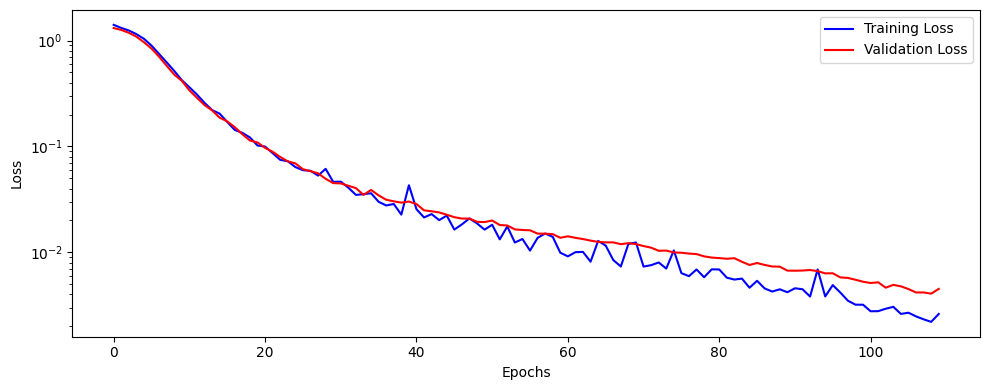

In [22]:
sbs.train(n_epochs=100)
sbs.plot_losses();

In [23]:
for key, value in sbs.val_report[-1].items():
    print(value)
    

1.0
[[55  0  0  0]
 [ 0 52  0  0]
 [ 0  0 40  0]
 [ 0  0  0 53]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        55
           1       1.00      1.00      1.00        52
           2       1.00      1.00      1.00        40
           3       1.00      1.00      1.00        53

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



In [24]:
#!tensorboard --logdir=runs

/tmp/ipykernel_356674/199847989.py:278: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


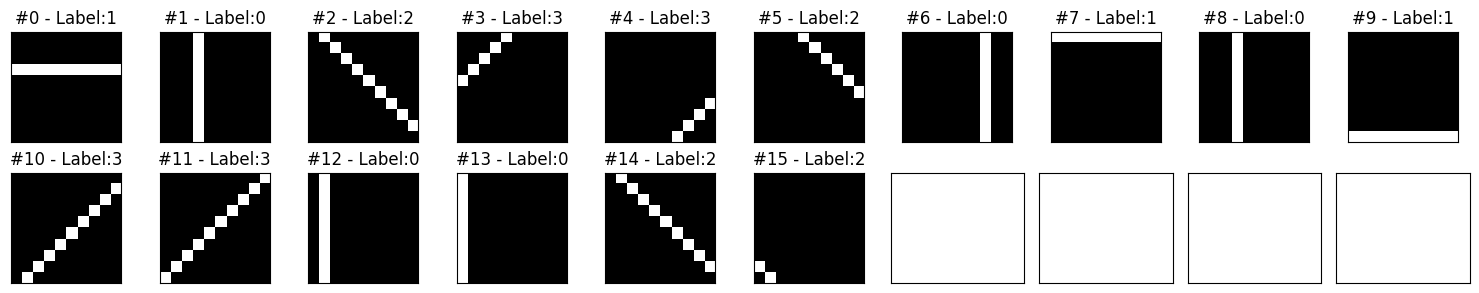

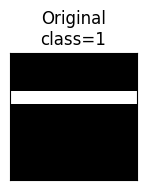

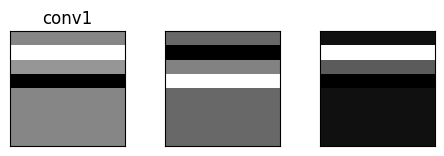

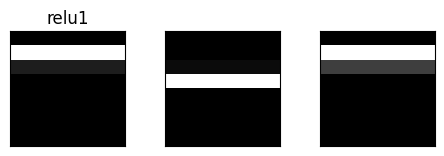

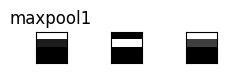

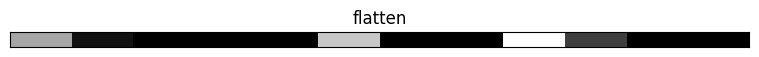

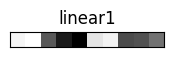

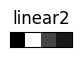

In [25]:
images_batch, labels_batch = next(iter(val_loader))
plot_images(images_batch,labels_batch, n_plot=16);


layers_to_hook=['conv1','relu1', 'maxpool1', 'flatten', 'linear1', 'linear2']
sbs.attach_hooks(layers_to_hook)
logits = sbs.predict(images_batch)
sbs._visualize_output(images_batch,labels_batch,1)
sbs.remove_hooks()

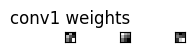

In [27]:
sbs._visualize_tensor(model.conv1.weight.detach().squeeze(1), note="conv1 weights")